In [188]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import r2_score, mean_squared_error

import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler

import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

from sklearn.linear_model import LinearRegression

In [189]:
df = pd.read_csv('/kaggle/input/linear-regression-dataset/kaggle.csv',sep=";",encoding= 'unicode_escape')

In [190]:
df

,age,shoe_size,price(£),sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f
5,8,31,7,m
6,9,30,6,f
7,9,30,7,m
8,10,29,8,f
9,11,32,5,m


In [191]:
df.rename(columns={'price(£)': 'price'}, inplace=True)

In [192]:
df

,age,shoe_size,price,sex
0,3,27,4,m
1,4,27,4,m
2,5,28,5,m
3,6,29,5,f
4,7,29,6,f
5,8,31,7,m
6,9,30,6,f
7,9,30,7,m
8,10,29,8,f
9,11,32,5,m


In [193]:
df.shape

(15, 4)

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        15 non-null     int64 
 1   shoe_size  15 non-null     int64 
 2   price      15 non-null     int64 
 3   sex        15 non-null     object
dtypes: int64(3), object(1)
memory usage: 608.0+ bytes


In [209]:
# Convert categorical 'sex' into numerical values
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])

In [197]:
df

,age,shoe_size,price,sex
0,3,27,4,1
1,4,27,4,1
2,5,28,5,1
3,6,29,5,0
4,7,29,6,0
5,8,31,7,1
6,9,30,6,0
7,9,30,7,1
8,10,29,8,0
9,11,32,5,1


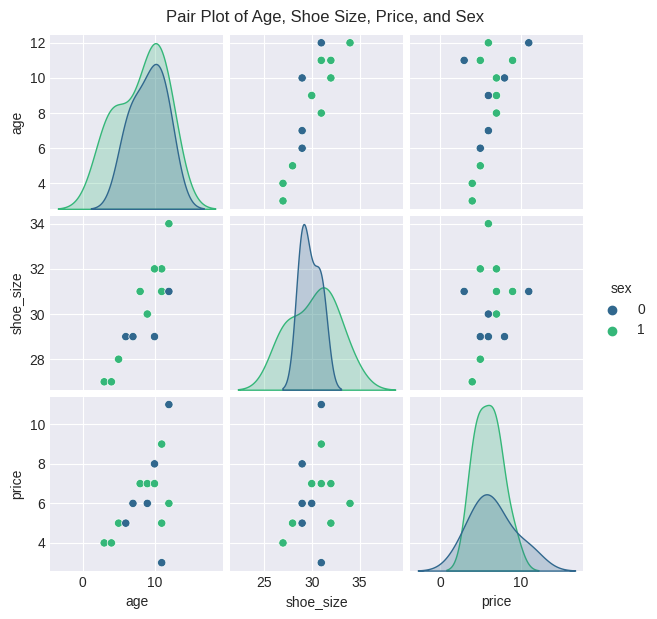

In [198]:
# Create a pair plot
sns.pairplot(df, hue="sex", palette="viridis", height=2)
plt.suptitle("Pair Plot of Age, Shoe Size, Price, and Sex", y=1.02)
plt.show()

In [199]:
# Define features and target
X = df[['age', 'shoe_size', 'price', 'sex']]
y = df['price']  # You can choose any column as target, assuming price is your target variable here

In [200]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [201]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [202]:
# Polynomial Regression (Degree 2 & 3)
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    # Model Evaluation
    print(f"🔹 Polynomial Regression (Degree {degree}):")
    print("MSE:", mean_squared_error(y_test, y_pred_poly))
    print("R² Score:", r2_score(y_test, y_pred_poly))
    print("-" * 40)

🔹 Polynomial Regression (Degree 2):
MSE: 0.856566715585077
R² Score: 0.7106193528428795
----------------------------------------
🔹 Polynomial Regression (Degree 3):
MSE: 0.862602089695247
R² Score: 0.7085803751029571
----------------------------------------


In [203]:
# Feature engineering: create new features
df['age_to_shoe_size_ratio'] = df['age'] / df['shoe_size']
df['age_and_price_interaction'] = df['age'] * df['price']

In [204]:
df

,age,shoe_size,price,sex,age_to_shoe_size_ratio,age_and_price_interaction
0,3,27,4,1,0.111111,12
1,4,27,4,1,0.148148,16
2,5,28,5,1,0.178571,25
3,6,29,5,0,0.206897,30
4,7,29,6,0,0.241379,42
5,8,31,7,1,0.258065,56
6,9,30,6,0,0.300000,54
7,9,30,7,1,0.300000,63
8,10,29,8,0,0.344828,80
9,11,32,5,1,0.343750,55


In [205]:
# Define features and target
X1 = df[['age', 'shoe_size', 'price', 'sex', 'age_to_shoe_size_ratio', 'age_and_price_interaction']]
y1 = df['price']  # You can adjust the target column

In [206]:
# Split the data into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

In [207]:
# 🔹 Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train1, y_train1)
y_pred_linear = linear_model.predict(X_test1)

In [208]:
# Polynomial Regression (Degree 2 & 3)
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train1)
    X_test_poly = poly.transform(X_test1)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train1)
    y_pred_poly = poly_model.predict(X_test_poly)

    # Model Evaluation
    print(f"🔹 Polynomial Regression (Degree {degree}):")
    print("MSE:", mean_squared_error(y_test1, y_pred_poly))
    print("R² Score:", r2_score(y_test1, y_pred_poly))
    print("-" * 40)

🔹 Polynomial Regression (Degree 2):
MSE: 0.01273089991180259
R² Score: 0.9956990203000667
----------------------------------------
🔹 Polynomial Regression (Degree 3):
MSE: 0.2993297335443229
R² Score: 0.8988750900188098
----------------------------------------


## Degree 3 model performs worse (Higher MSE, Lower R²).

## This indicates overfitting with Degree 3 because adding more polynomial terms doesn’t improve performance.
## Fix: Stick to Degree 2 Polynomial Regression, as it generalizes better.

# Thank you